### Data description
There are 3 types of input features:

*Objective*: factual information;
*Examination*: results of medical examination;
*Subjective*: information given by the patient.

#### Features:

* Age | Objective Feature | age | int (days)
* Height | Objective Feature | height | int (cm) |
* Weight | Objective Feature | weight | float (kg) |
* Gender | Objective Feature | gender | categorical code |
* Systolic blood pressure | Examination Feature | ap_hi | int |
* Diastolic blood pressure | Examination Feature | ap_lo | int |
* Cholesterol | Examination Feature | cholesterol | 1: normal, 2: above normal, 3: well above normal |
* Glucose | Examination Feature | gluc | 1: normal, 2: above normal, 3: well above normal |
* Smoking | Subjective Feature | smoke | binary |
* Alcohol intake | Subjective Feature | alco | binary |
* Physical activity | Subjective Feature | active | binary |
* Presence or absence of cardiovascular diseasec (**Diagnostic**) | Target Variable | cardio | binary |

All of the dataset values were collected at the moment of medical examination.

The dataset contains 70,000 patient records with 11 features across three categories 
- bjective measurements (age, height, weight, gender), 
- examination results (systolic BP, diastolic BP, cholesterol, glucose), and 
- self-reported lifestyle factors (smoking, alcohol, physical activity). 

The target variable 'cardio' encodes presence or absence of a cardiovascular disease diagnosis."

**Limitation**
Importantly, the target variable records diagnostic outcome rather than confirmed biological disease presence. Given well-documented systematic underdiagnosis of CVD in women, a negative label cannot be assumed to reliably confirm absence of disease in female patients

In [126]:
# import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import os

data = pd.read_csv(os.path.join("data/raw/cardio_train.csv"))

# Data exploration

# print(data.columns)
# # Null values : no null values in the dataset
# # print(data.isnull().sum())
# # Negative Values : 
# print((data < 0).sum())
# # print(pd.concat([data.head(5), data.sample(5), data.tail(5)]))

# print(data.describe(include="all").transpose())


In [127]:

# Unsual BP values
# Systolic > 250 mmHg and Diastolic > 150 mmHg are considered extremely high and may indicate a hypertensive crisis, which is a medical emergency. Such high blood pressure readings can lead to severe health complications, including stroke, heart attack, or organ damage. It is crucial for individuals with such readings to seek immediate medical attention to manage their blood pressure and prevent potential life-threatening consequences.
print(data[data["ap_hi"] > 250].shape[0])
print(data[data["ap_lo"] > 150].shape[0])
print((data["ap_hi"] < 70).sum())
print((data["ap_lo"] < 40).sum())
print((data["ap_lo"] > data["ap_hi"]).sum())

# Getting ranges
high_sys = data[data["ap_hi"] > 250]["ap_hi"]
print("Systolic >250 range:", high_sys.min(), "to", high_sys.max())

high_dia = data[data["ap_lo"] > 150]["ap_lo"]
print("Diastolic >150 range:", high_dia.min(), "to", high_dia.max())

# Print where ap_hi < ap_lo -> not possible
print(data[data["ap_hi"] < data["ap_lo"]].shape[0])
data["age_years"] = (data["age"] / 365.25).round().astype(int)
data["gender"] = data["gender"].replace({1: 0, 2: 1})# 0=female, 1=male
# print(data["gender"].unique())          # should be [0, 1]

# print("Gender vales", data["gender"].value_counts()) 
# print(data["gender"].isnull().sum())

40
975
189
59
1234
Systolic >250 range: 309 to 16020
Diastolic >150 range: 160 to 11000
1234


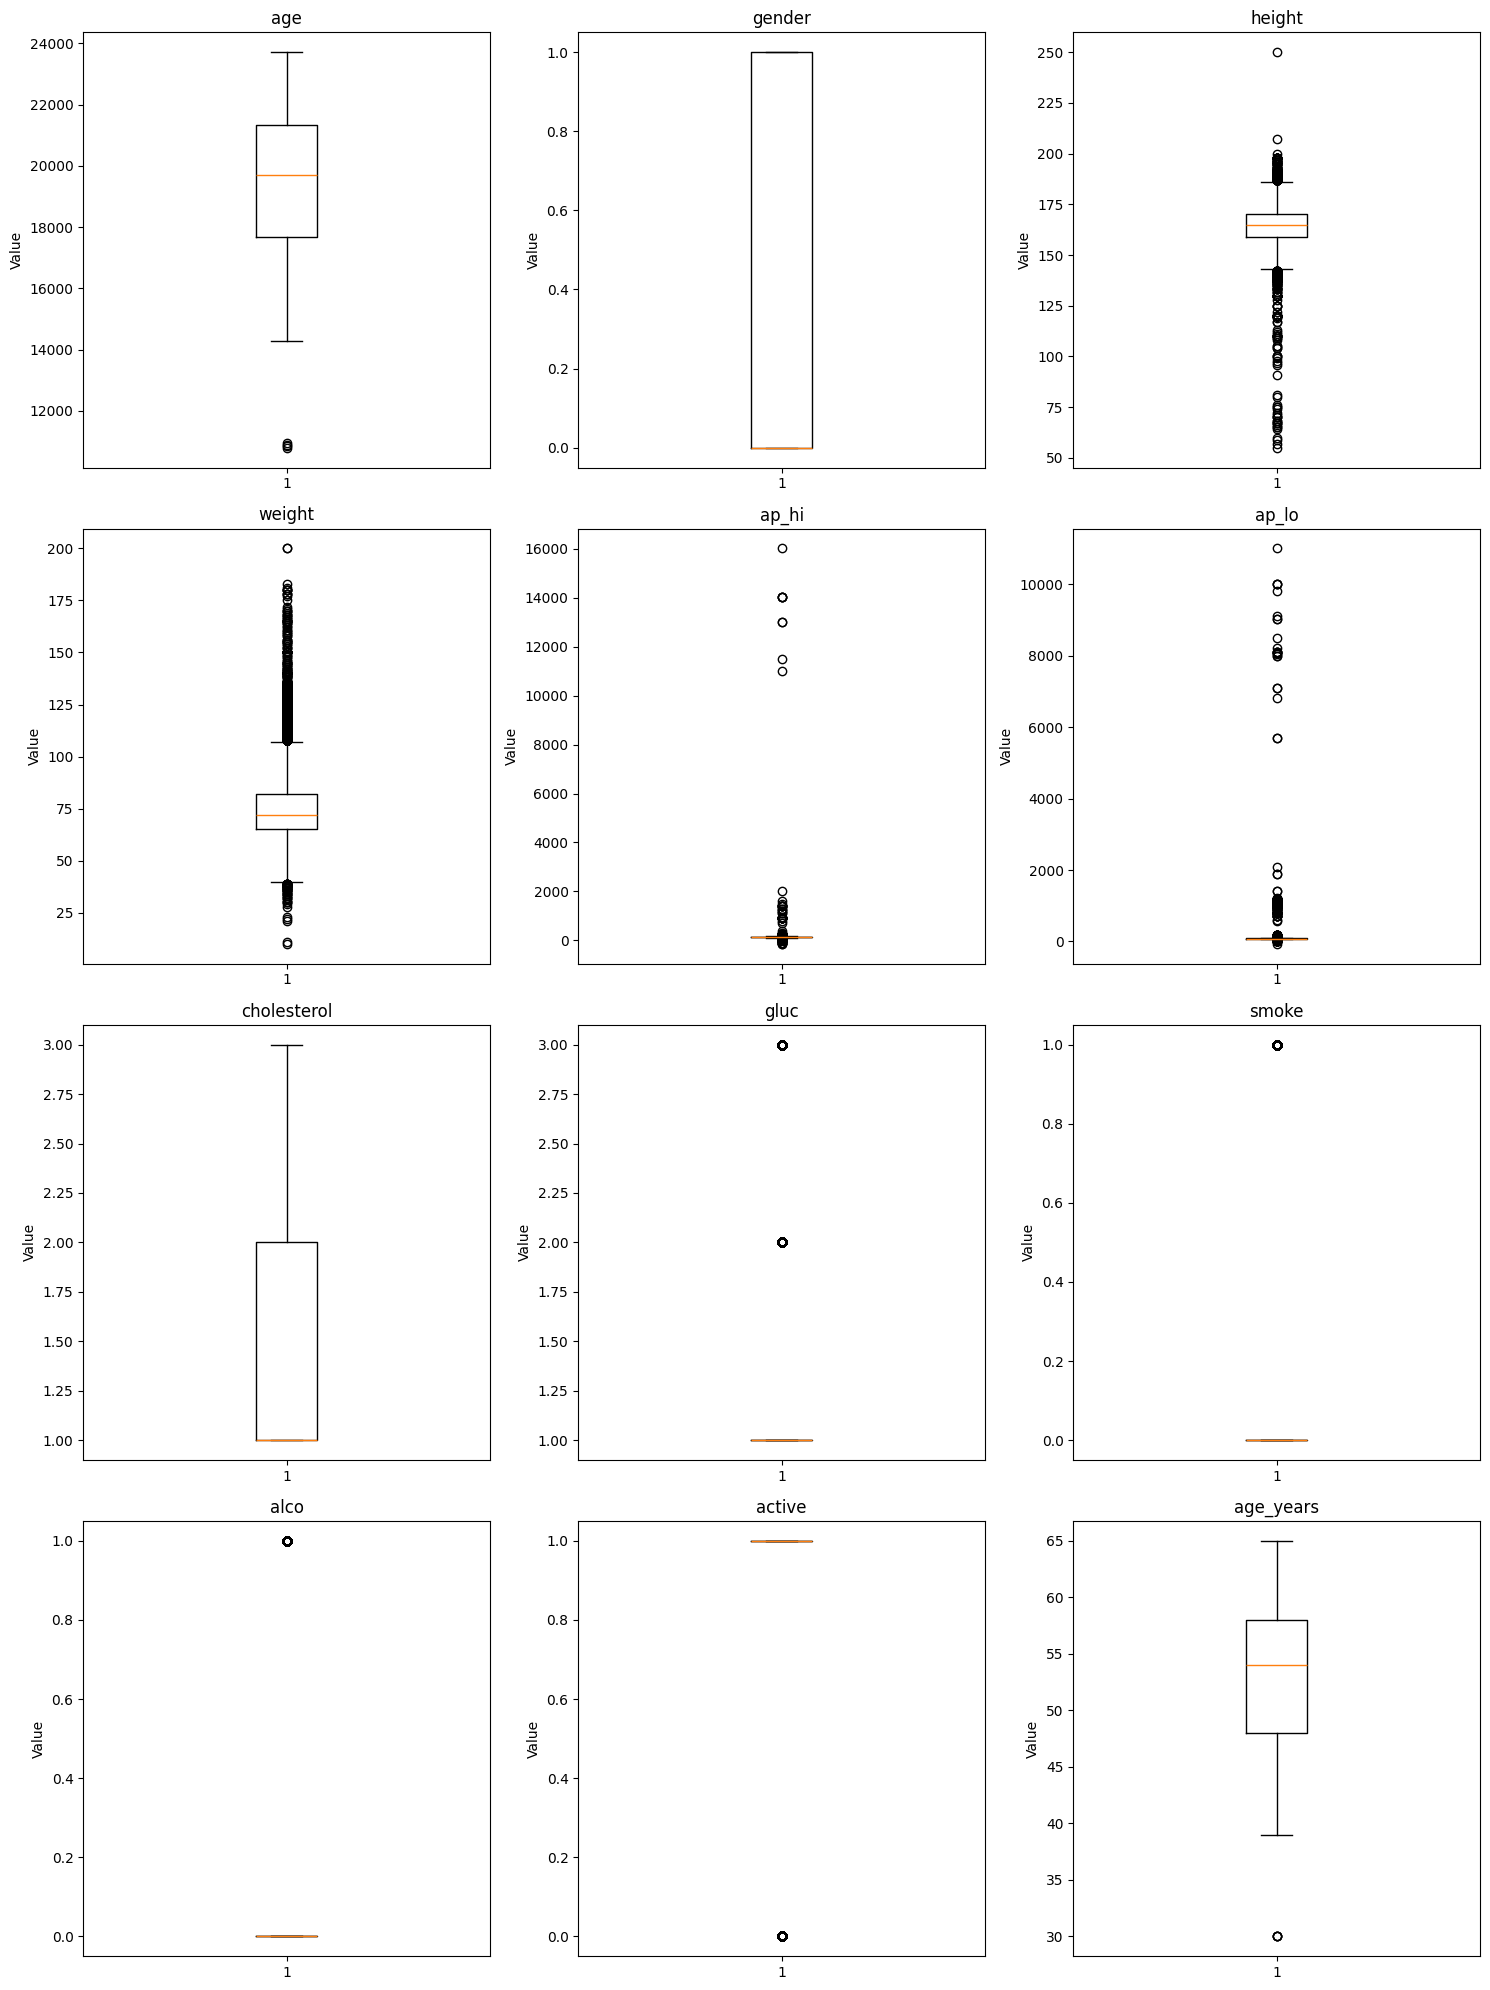

In [128]:
# Outliers - Box plots
import matplotlib.pyplot as plt
import numpy as np

# Drop target and ID (ID should not be analysed)
features = data.drop(columns=["cardio", "id"])

# Select only numeric columns
numeric_cols = features.select_dtypes(include=["int64", "float64"]).columns

# Determine grid size
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(features[col], vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [129]:

# Define outlier thresholds and filter

df = data.copy()

# --- If you already converted age to years and renamed it ---
# If your column is still "age" in days, convert first:
# df["age_years"] = df["age"] / 365.25

# If you already have age in years in df["age"], then do:
# df["age_years"] = df["age"]

# 1) Create/ensure age_years exists (adjust this line to your setup)
# print("Height over 195:", (df["height"] >= 195).sum())

def apply_filter(df, mask, name):
    before = df.shape[0]
    df = df[mask].copy()
    after = df.shape[0]
    print(f"{name:35s} | kept {after:6d}/{before:6d} | removed {before - after:6d}")
    return df


# adding BMI to remove impossible cases
df["BMI"] = df["weight"] / (df["height"]/100)**2
print(df["BMI"].describe())

print((df["BMI"] > 70).sum())


count    70000.000000
mean        27.556513
std          6.091511
min          3.471784
25%         23.875115
50%         26.374068
75%         30.222222
max        298.666667
Name: BMI, dtype: float64
36


In [130]:
# --- Age filter ---
df = apply_filter(df, (df["age_years"] >= 30) & (df["age_years"] <= 65), "Age 30–65 years")

# --- Height & weight filters ---
df = apply_filter(df, (df["height"] >= 140) & (df["height"] <= 220), "Height 140–200 cm")
df = apply_filter(df, (df["weight"] >= 45) & (df["weight"] <= 200), "Weight 30–200 kg")

# --- Blood pressure filters --
df = apply_filter(df, (df["ap_hi"] >= 70) & (df["ap_hi"] <= 200), "Systolic (ap_hi) 70–200")
df = apply_filter(df, (df["ap_lo"] >= 40) & (df["ap_lo"] <= 150), "Diastolic (ap_lo) 40–150")
df = apply_filter(df, df["ap_lo"] <= df["ap_hi"], "Diastolic <= Systolic")

# --- Cholesterol & glucose allowed values ---
df = apply_filter(df, df["cholesterol"].isin([1, 2, 3]), "Cholesterol in {1,2,3}")
df = apply_filter(df, df["gluc"].isin([1, 2, 3]), "Glucose in {1,2,3}")
# Clipping height cause below 140 is very rare for adults

# --- Lifestyle & target must be binary ---
for col in ["smoke", "alco", "active", "cardio"]:
    df = apply_filter(df, df[col].isin([0, 1]), f"{col} in {{0,1}}")

df = df.drop(columns=["id", "age"])  # Drop the ID
print("\nFinal cleaned shape:", df.shape)

Age 30–65 years                     | kept  70000/ 70000 | removed      0
Height 140–200 cm                   | kept  69847/ 70000 | removed    153
Weight 30–200 kg                    | kept  69554/ 69847 | removed    293
Systolic (ap_hi) 70–200             | kept  69269/ 69554 | removed    285
Diastolic (ap_lo) 40–150            | kept  68266/ 69269 | removed   1003
Diastolic <= Systolic               | kept  68180/ 68266 | removed     86
Cholesterol in {1,2,3}              | kept  68180/ 68180 | removed      0
Glucose in {1,2,3}                  | kept  68180/ 68180 | removed      0
smoke in {0,1}                      | kept  68180/ 68180 | removed      0
alco in {0,1}                       | kept  68180/ 68180 | removed      0
active in {0,1}                     | kept  68180/ 68180 | removed      0
cardio in {0,1}                     | kept  68180/ 68180 | removed      0

Final cleaned shape: (68180, 13)


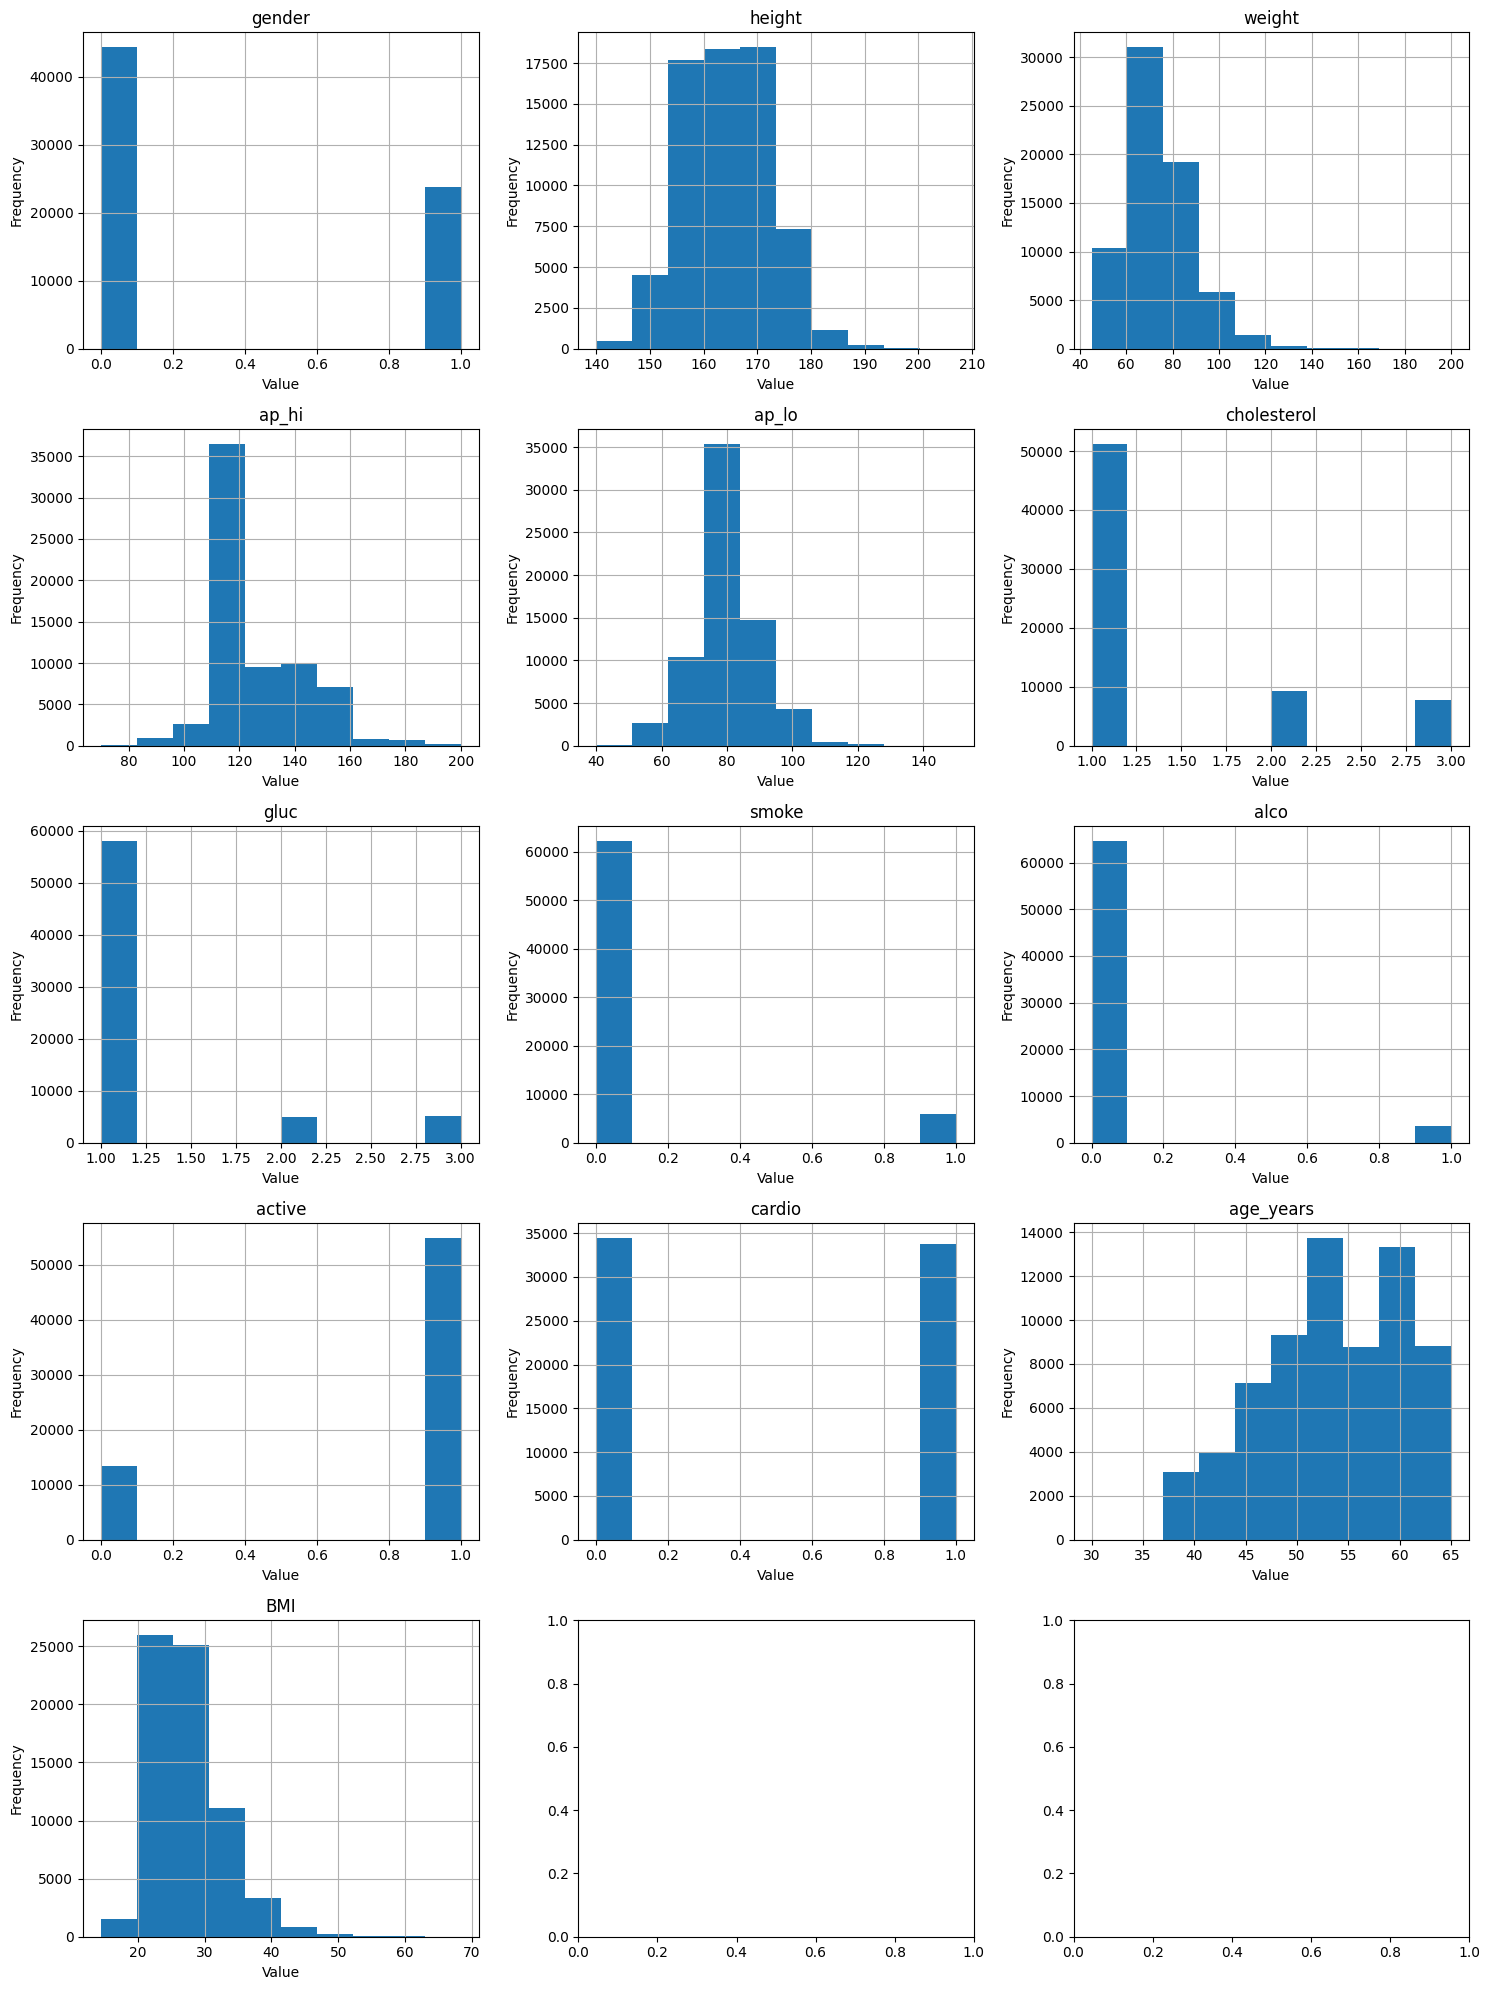

In [131]:
# Histograms for each feature
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

fig, axes = plt.subplots(nrows = 5, ncols = 3, figsize=(15, 20))

axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df[col].hist(ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    
plt.tight_layout()
plt.show()



 BMI seems to be fin with some exxtreme cases over 60; keeping since it is clinically possible
 BMI not used in training

## Gender based Histograms to see more imbalance

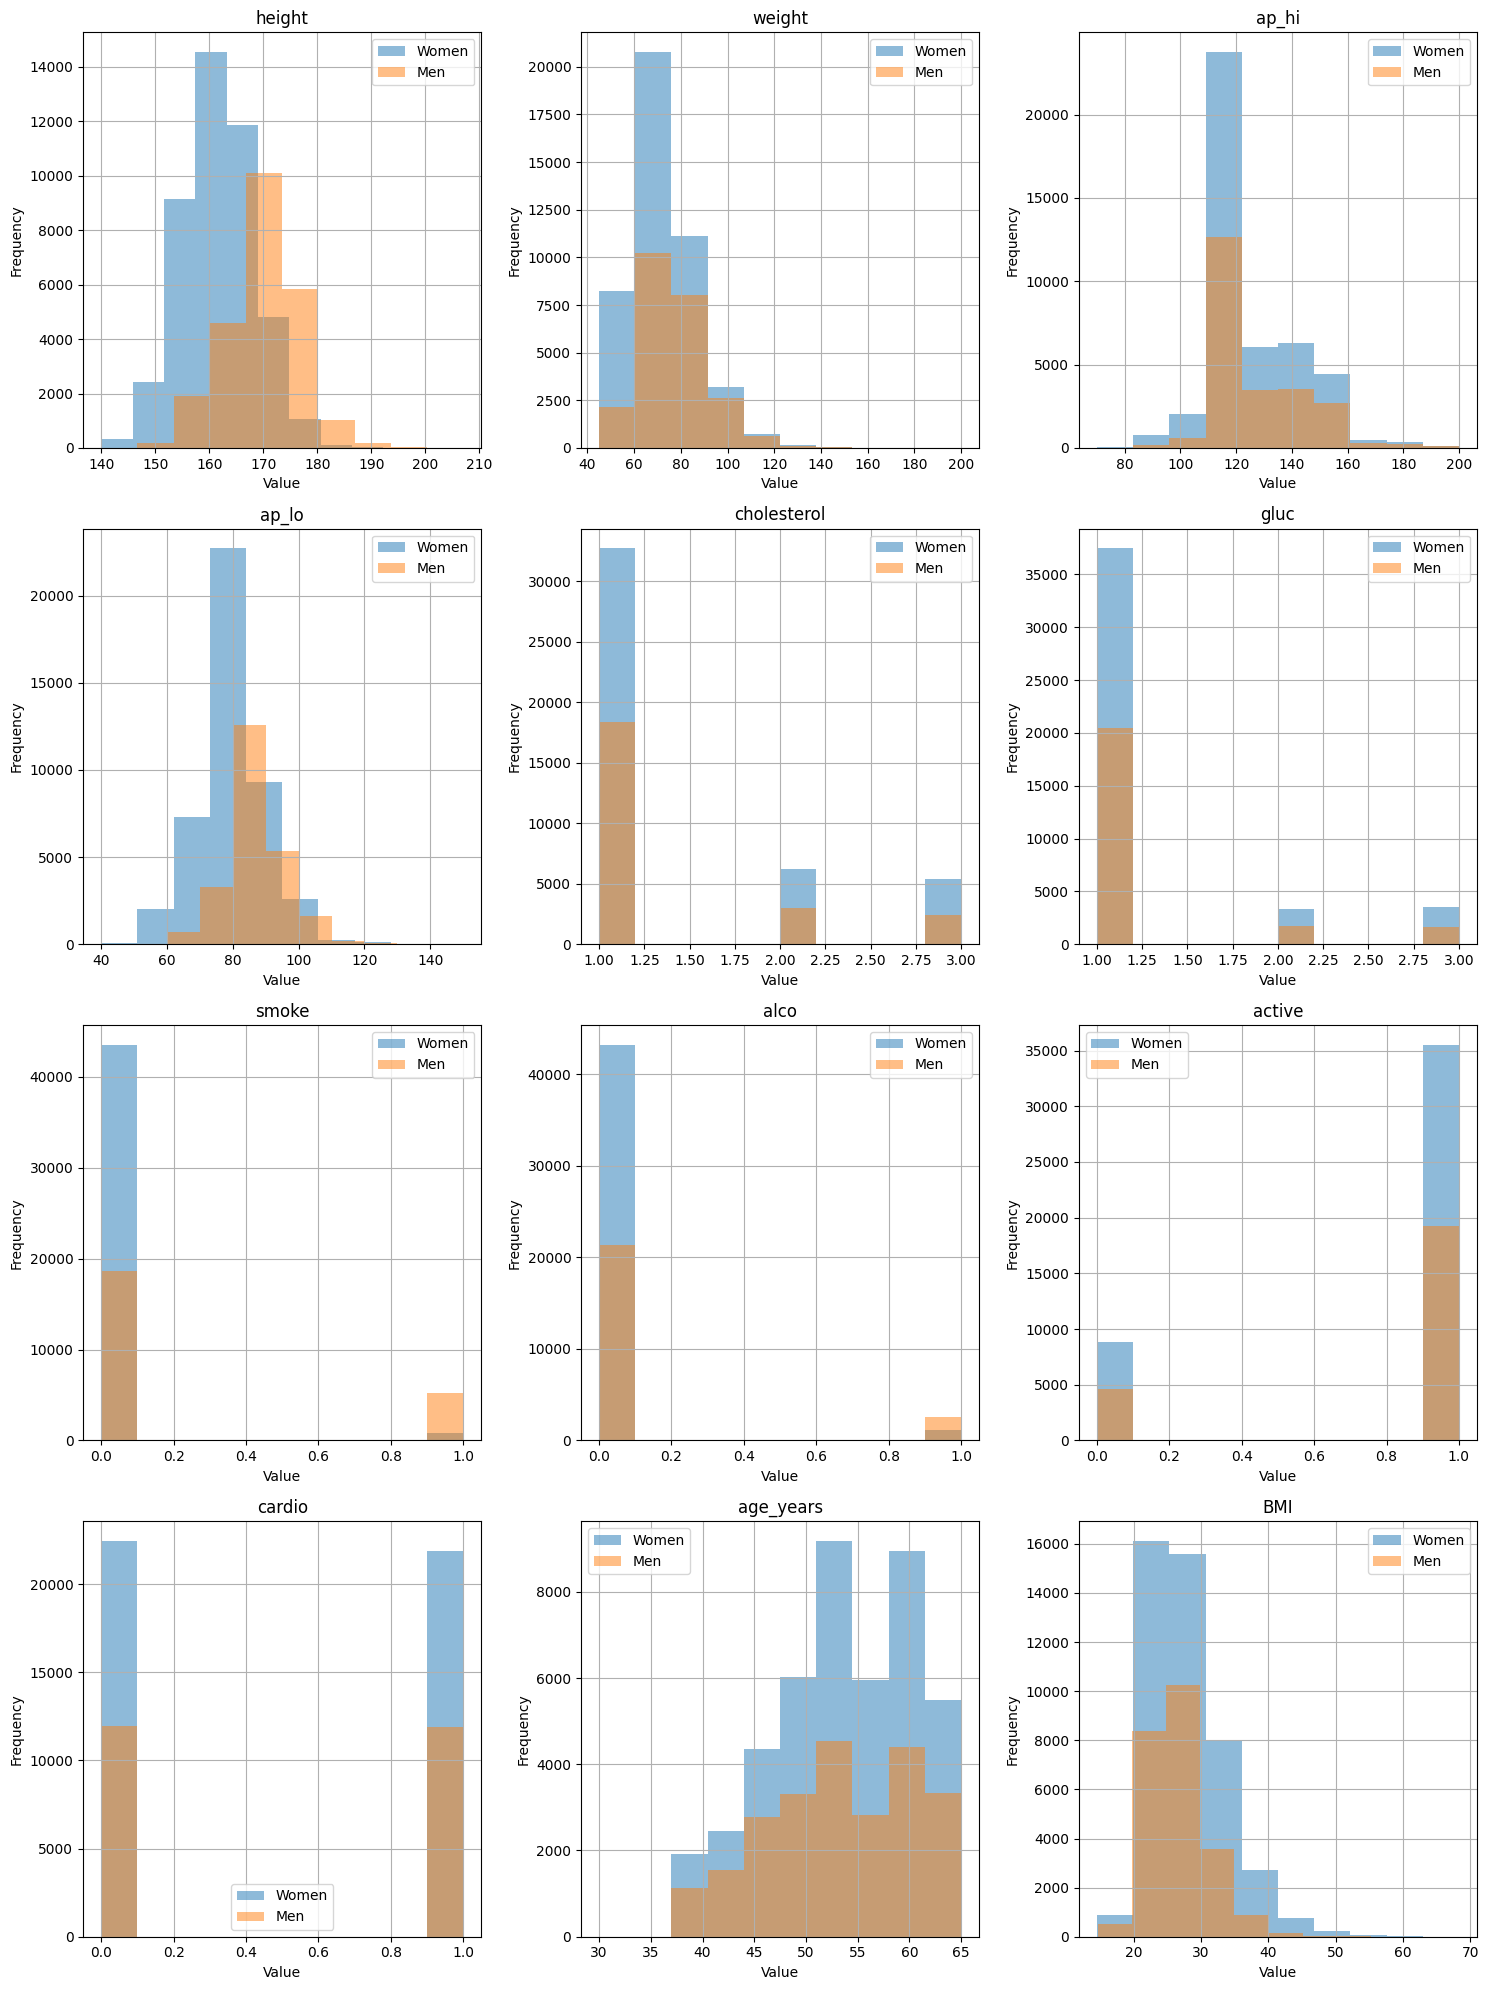

In [132]:
# --- Histograms by gender ---
numeric_cols = [c for c in numeric_cols if c not in ["gender"]]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    df[df["gender"] == 0][col].hist(ax=axes[idx], alpha=0.5, label="Women")
    df[df["gender"] == 1][col].hist(ax=axes[idx], alpha=0.5, label="Men")

    axes[idx].set_title(col)
    axes[idx].set_xlabel("Value")
    axes[idx].set_ylabel("Frequency")
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [154]:
# df=df.drop(columns="BMI")
# Dont want BMI in training
df.to_csv("data/processed/cardio_baseline_clean.csv", index=False)
print(df.columns)
# print(df.groupby("smoke")["cardio"].mean())
# print(df.groupby("alco")["cardio"].mean())
# print(df.groupby("gluc")["cardio"].mean())
# print(df.groupby("cholesterol")["cardio"].mean())
# print(df.groupby("gender")["cardio"].mean())
df_women = df[df["gender"] == 0]
# print(df_women.groupby(df_women["ap_hi"] < 130)["cardio"].mean())
# print(df_women.groupby(df_women["age_years"] < 50)["cardio"].mean())
df_gluc_chol = df[(df["gluc"] == 3)  & (df["cholesterol"] == 3)]
print(df_gluc_chol.columns)
print(df_gluc_chol.groupby("gender")["cardio"].value_counts())
# print(df_women.sum())
df_NoCVD_130below_women = df_women[(df_women["cardio"] == 0) & (df_women["ap_hi"] < 130)].copy()
# print(df_NoCVD_130below_women.mean())

Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years'],
      dtype='str')
Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years'],
      dtype='str')
gender  cardio
0       1         1647
        0          737
1       1          666
        0          315
Name: count, dtype: int64


In [134]:
print(pd.crosstab(df["gender"], df["cholesterol"], normalize="index"))
print(pd.crosstab(df["gender"], df["gluc"], normalize="index"))

df.groupby("gender")[["smoke","alco","active"]].mean()

cholesterol         1         2         3
gender                                   
0            0.738411  0.139751  0.121839
1            0.771205  0.127039  0.101757
gluc           1         2         3
gender                              
0       0.845068  0.074895  0.080038
1       0.859629  0.071695  0.068676


,smoke,alco,active
gender,,,
0,0.017731,0.025198,0.801552
1,0.219278,0.106033,0.806423


* Cholesterol - Proportions similar across gender (women have slightly higher chol in dataset - very less difference)
* Glucose - also similar - More women in category 3, minor difference tho
* Smoking - Huge difference - 1.8 % women are smokers compared to 21.9% men being smokers (Men smoke 12x more often) - Model learns strong gender correlation
* Alcohol - 2.5% women drink alcohol, 10.6% men drink alcohol (Men drink 4x more)
**Note** - Since Smoking and Alcohol are self reported, due to social implications women are likely to underreport their habits so this is not as unreliable - might have to look into how to deal with this lol
* Physical Activity - Similar again

## Different Feature combinations
1. BSA 
2. Pulse pressure?
3. Health indicator maybe
4. Chol and glucose interaction since both are 0.45 correlated

Will need to see indicators



In [135]:
# # Adding BSA
# df["BSA"] = np.sqrt((df["height"] * df["weight"]) / 3600).round(2)
# # Keeping to 2 decimal places
# df['Pulse pressure'] = df['ap_hi'] - df['ap_lo']
# df["chol_gluc_interaction"] = df["cholesterol"] * df["gluc"]
# df = df.drop(columns = "height")


# df.to_csv("data/processed/cardio_bsa_pp.csv", index=False)